##§1. ライブラリのインポート
まず、必要なライブラリをインポートします。
- `pandas`: データ操作のため
- `sklearn.preprocessing.StandardScaler`: データを標準化するため
- `sklearn.cluster.KMeans`: K-Meansクラスタリングのため
- `matplotlib.pyplot`, `seaborn`: 結果を可視化するため

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語表示対応
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
!pip install japanize_matplotlib
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# japanize-matplotlibをインポートするだけで、日本語フォントが自動で設定されます。

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 38.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b2ed0bc39af202db6745f45cec4705cdad496447a4e308fb0a3f102add2dfa9e
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## §2. データの読み込み
`/content/pokemon.csv`からポケモンの種族値データを読み込みます。

**種族値の内訳:**
- HP (Hit Point)
- こうげき (Attack)
- ぼうぎょ (Defense)
- とくしゅ  (Special)
- すばやさ (Speed)

これらの合計を「合計種族値」とします。

In [8]:
import pandas as pd

# CSVファイルを読み込みます。日本語が含まれることが多いため encoding='utf-8' を指定します。
df = pd.read_csv('/content/pokemon.csv', encoding='utf-8')

# データの最初の5行を表示して、正しく読み込めているか確認します。
display(df.head())

,番号,種族名,HP,こうげき,ぼうぎょ,とくしゅ,すばやさ,合計
0,1,フシギダネ,45,49,49,65,45,253
1,2,フシギソウ,60,62,63,80,60,325
2,3,フシギバナ,80,82,83,100,80,425
3,4,ヒトカゲ,39,52,43,50,65,249
4,5,リザード,58,64,58,65,80,325


## §3. データの準備と標準化
クラスタリングに使う種族値の列を選び、`StandardScaler`を使ってデータを標準化します。これにより、各ステータスのスケールが揃えられ、特定のステータスがクラスタリングに過度に影響を与えるのを防ぎます。

In [9]:
from sklearn.preprocessing import StandardScaler

# 現在のデータフレームにある列名に合わせて指定します
status = ['HP', 'こうげき', 'ぼうぎょ', 'とくしゅ', 'すばやさ']

# 特徴量を抽出
X = df[status]

# 標準化の実行
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.astype("float32")


print(f"標準化完了。データの形状: {X_scaled.shape}")
display(pd.DataFrame(X_scaled, columns=status).head())

標準化完了。データの形状: (151, 5)


,HP,こうげき,ぼうぎょ,とくしゅ,すばやさ
0,-0.674214,-0.886322,-0.711984,-0.149623,-0.898145
1,-0.147811,-0.391484,-0.191716,0.378252,-0.332119
2,0.554059,0.369805,0.551523,1.082085,0.422583
3,-0.884775,-0.772129,-0.934955,-0.677497,-0.143443
4,-0.217998,-0.315355,-0.377526,-0.149623,0.422583


## §4. K-Meansクラスタリングの適用
K-Meansアルゴリズムを適用します。ここでは、クラスターの数を`n_clusters=3`としていますが、これは「エルボー法」などを用いて最適な数を決定することが推奨されます。

**エルボー法（補足）:**
クラスターの数（k）を増やしながら、各クラスター内の点と中心の距離の合計（WSS: Within-cluster Sum of Squares）を計算します。WSSが急激に減少する点が「肘」のように見えるため、その点を最適なkと判断します。

In [10]:
from sklearn.cluster import KMeans

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# クラスタリング結果の確認
display(df[['種族名', 'Cluster']].head(10))

,種族名,Cluster
0,フシギダネ,0
1,フシギソウ,0
2,フシギバナ,2
3,ヒトカゲ,0
4,リザード,3
5,リザードン,3
6,ゼニガメ,0
7,カメール,1
8,カメックス,2
9,キャタピー,0


### (参考) エルボー法で最適なクラスター数を決定する
エルボー法を使って、最適なクラスター数を推定してみましょう。最適なクラスター数が見つかれば、上記の`n_clusters`を修正して再実行してください。

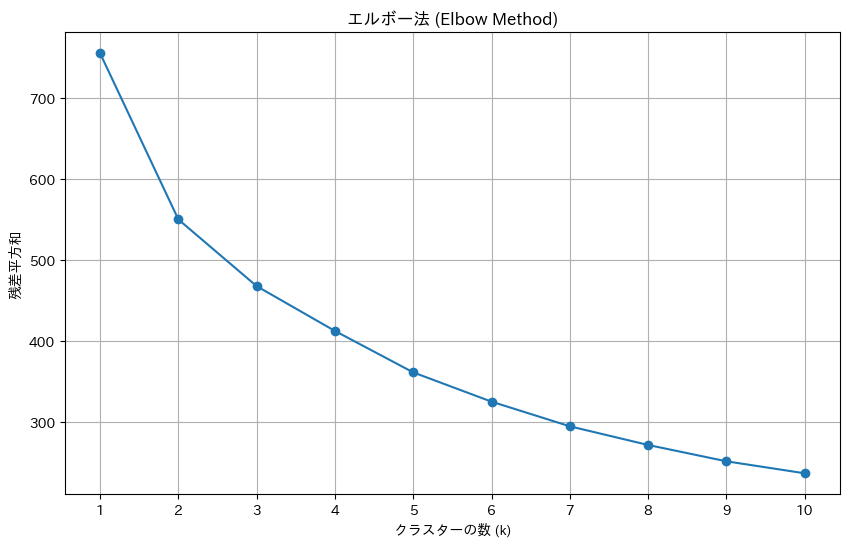

In [11]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('エルボー法 (Elbow Method)')
plt.xlabel('クラスターの数 (k)')
plt.ylabel('残差平方和')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## §5. クラスタリング結果の可視化
クラスタリング結果を視覚的に確認します。今回は主成分分析（PCA）を用いて次元を削減し、2次元でプロットします。これにより、各ポケモンがどのクラスターに属しているか、視覚的に理解しやすくなります。

**補足:**
もしPCAを使わずに、特定の2つのステータス（例：こうげきとぼうぎょ）の関係でクラスタリング結果を見たい場合は、適宜コードを修正してください。

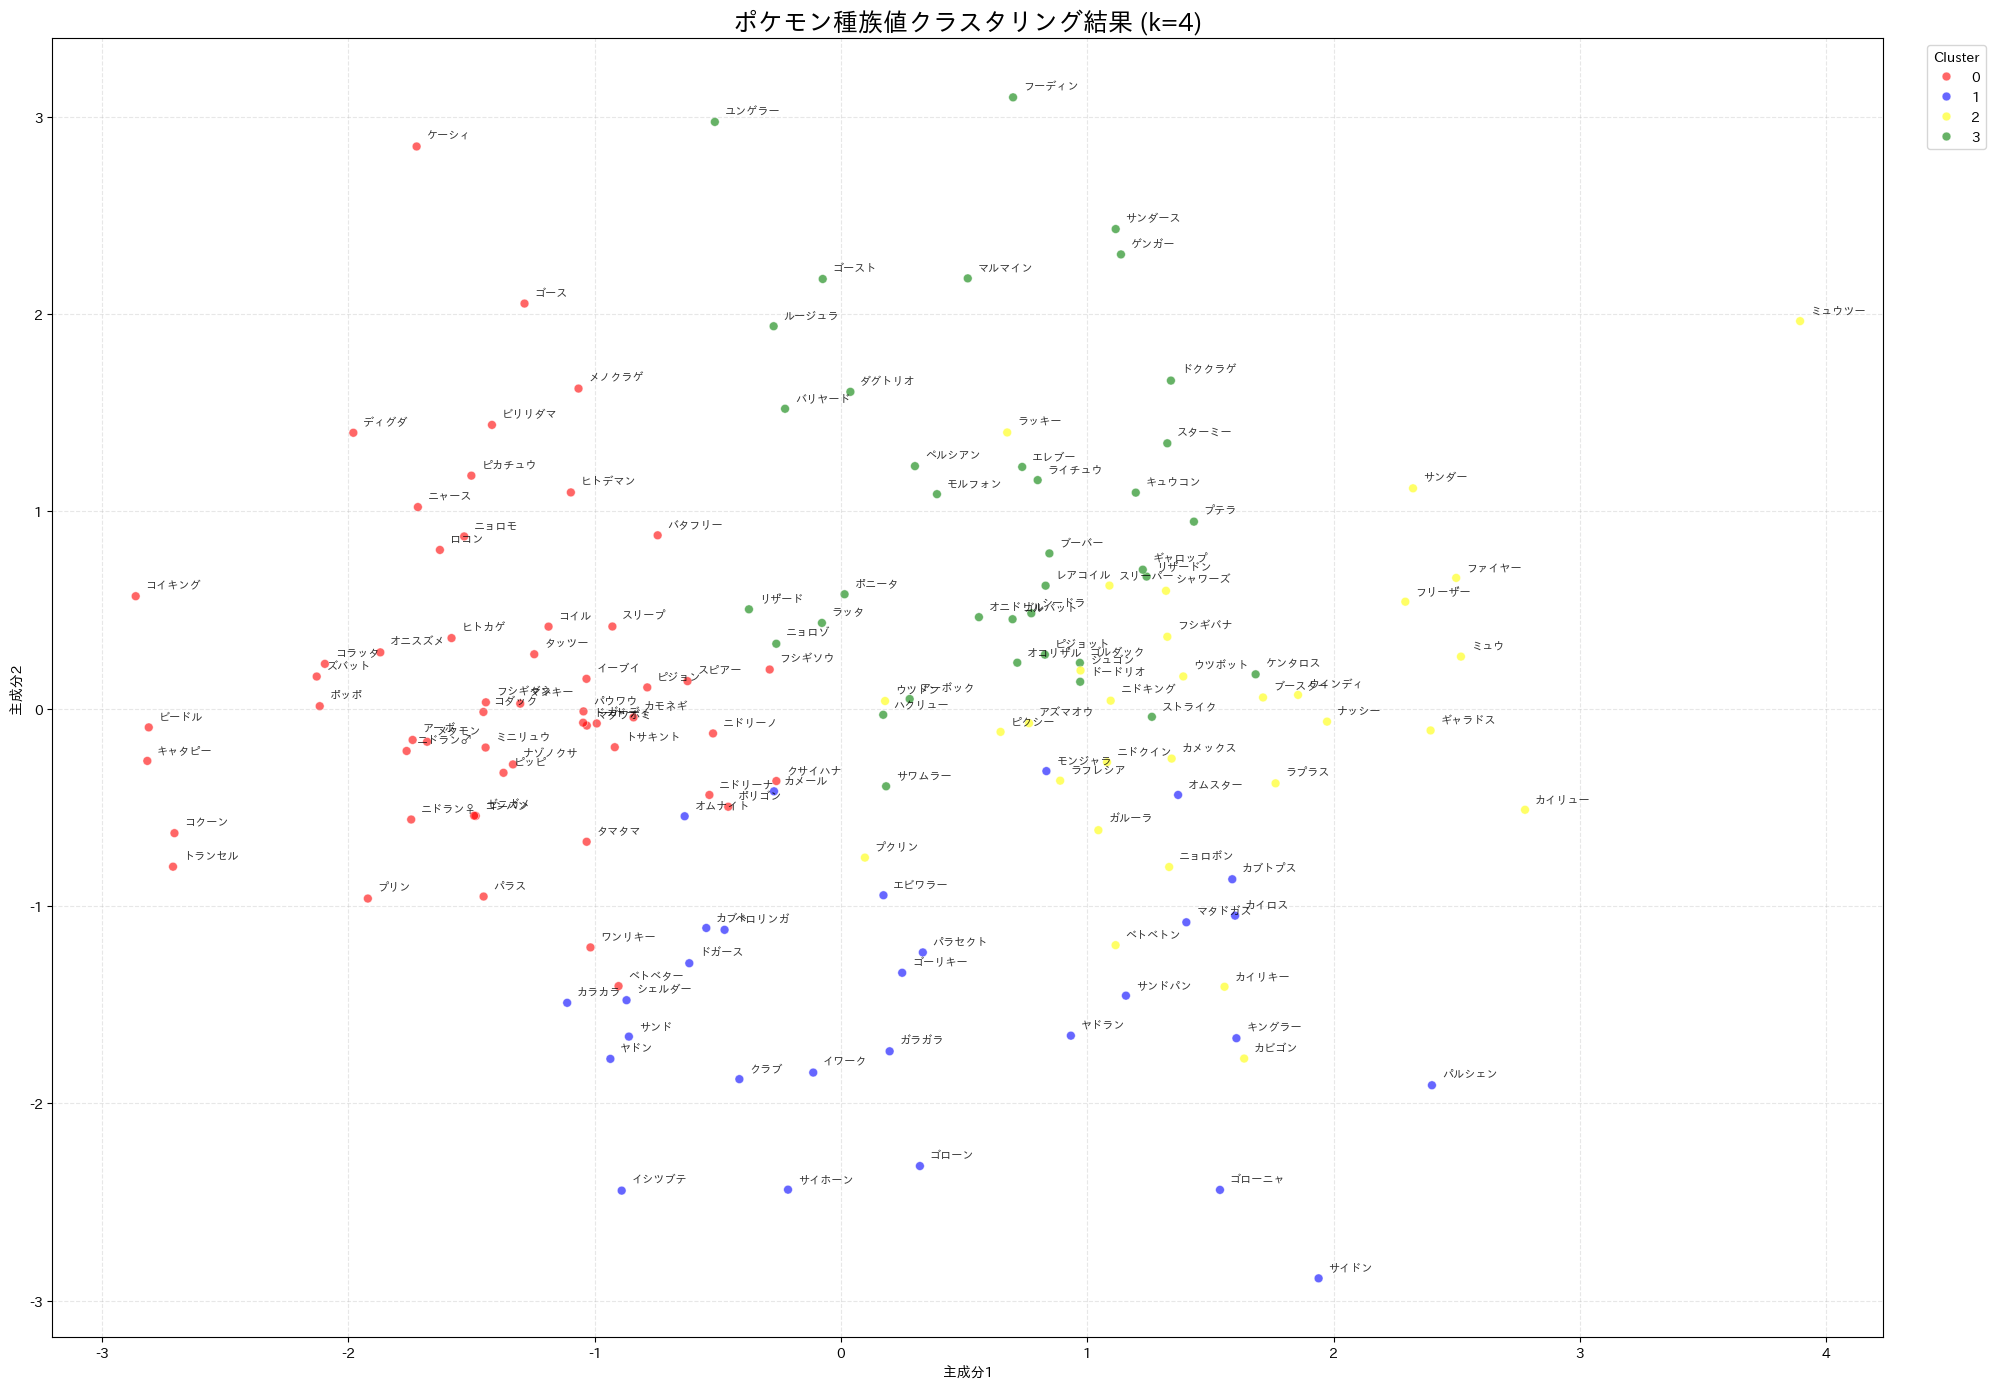

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

# PCAによる次元削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# プロット用データフレームの作成
df_pca = pd.DataFrame(data=X_pca, columns=['主成分1', '主成分2'])
df_pca['Cluster'] = df['Cluster'].values
df_pca['種族名'] = df['種族名'].values

# カスタムカラーパレットの設定（赤、青、黄、緑）
custom_palette = ['red', 'blue', 'yellow', 'green']

# 描画設定
plt.figure(figsize=(20, 14))
sns.scatterplot(x='主成分1', y='主成分2', hue='Cluster', palette=custom_palette, data=df_pca, s=40, alpha=0.6)

# 全ての名前を描画
for i, row in df_pca.iterrows():
    plt.text(row['主成分1']+0.04, row['主成分2']+0.04, row['種族名'], fontsize=8, alpha=0.8)

plt.title(f'ポケモン種族値クラスタリング結果 (k={n_clusters})', fontsize=18)
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
import plotly.express as px

# 色の対応を確実にするため、Clusterを文字列型に一時的に変換します
df_pca['Cluster_str'] = df_pca['Cluster'].astype(str)

# Plotlyを使用してインタラクティブな散布図を作成
fig = px.scatter(
    df_pca,
    x='主成分1',
    y='主成分2',
    color='Cluster_str',
    hover_name='種族名',
    # クラスタ番号(文字列)と色の対応を明示的に指定
    color_discrete_map={'0': 'red', '1': 'blue', '2': 'yellow', '3': 'green'},
    category_orders={'Cluster_str': ['0', '1', '2', '3']},
    title=f'ポケモン種族値クラスタリング結果 (k={n_clusters}) - インタラクティブ版',
    labels={'主成分1': '主成分1', '主成分2': '主成分2', 'Cluster_str': 'Cluster'},
    width=1000,
    height=700
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

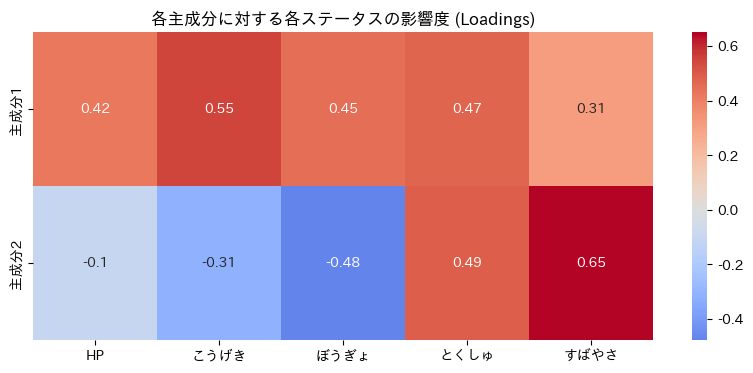

【主成分の解釈】
主成分1: 最も正の影響が大きいのは「こうげき」、負の影響（または低い影響）は「すばやさ」です。
主成分2: 最も正の影響が大きいのは「すばやさ」、負の影響（または低い影響）は「ぼうぎょ」です。


In [14]:
import numpy as np

# 各主成分の構成要素（ウェイト）を確認
components = pd.DataFrame(
    pca.components_,
    columns=status,
    index=['主成分1', '主成分2']
)

# ヒートマップで可視化
plt.figure(figsize=(10, 4))
sns.heatmap(components, annot=True, cmap='coolwarm', center=0)
plt.title('各主成分に対する各ステータスの影響度 (Loadings)')
plt.show()

# 解説の表示
print("【主成分の解釈】")
for i in range(2):
    top_attr = components.iloc[i].idxmax()
    low_attr = components.iloc[i].idxmin()
    print(f"主成分{i+1}: 最も正の影響が大きいのは「{top_attr}」、負の影響（または低い影響）は「{low_attr}」です。")

主成分の意味の読み解き方

上のヒートマップで**赤いほど正の相関**、**青いほど負の相関**が強いことを示します。

1.  **主成分1 (PC1)**: おそらくすべての項目がプラス（赤～薄赤）になっているはずです。これは、この軸が「全般的なステータスの高さ（強さ）」を表していることを意味します。右に行くほど伝説のポケモンや進化後などの強力なポケモンが配置されます。
2.  **主成分2 (PC2)**: プラスとマイナスの項目に分かれていることが多いです。例えば、上に行くほど: 「すばやさが高い」傾向にあり、同時に「ぼうぎょが低い」傾向がある（高速アタッカー寄り）
下に行くほど: 「すばやさが低い」傾向にあり、同時に「ぼうぎょが高い」傾向がある（鈍足タンク寄り）

## §6. 各クラスターの特徴分析
各クラスターに属するポケモンの平均種族値を確認することで、それぞれのクラスターがどのような特徴を持つポケモンを集めているかを理解できます。

In [31]:
cluster_summary = df.groupby('Cluster')[status].mean()

# スタイルをチェーン（連結）させて、最大値を赤・最小値を青に同時に設定します
styled_summary = cluster_summary.style\
    .highlight_max(axis=0, props='color:red;')\
    .highlight_min(axis=0, props='color:blue;')

display(styled_summary)
print(f"{n_clusters}分割での各ステータスの平均値です。最大値を赤、最小値を青く表示しています。")

,HP,こうげき,ぼうぎょ,とくしゅ,すばやさ
Cluster,,,,,
0,47.854545,51.909091,47.254545,53.581818,57.218182
1,60.310345,83.896552,103.931034,56.724138,48.413793
2,100.400000,91.933333,76.133333,93.466667,71.833333
3,62.243243,77.540541,64.729730,82.729730,99.540541


4分割での各ステータスの平均値です。最大値を赤、最小値を青く表示しています。


この出力から、各クラスターがどのような傾向のポケモンをまとめているかを分析できます。
例えば、
- あるクラスターは「HPとぼうぎょが高いタンク型」
- 別のクラスターは「こうげきとすばやさが高いアタッカー型」
といった特徴が見出せるかもしれません。

## §７. 各クラスターに属するポケモンの確認
各クラスターに具体的にどのポケモンが属しているかを一覧で表示します。

In [ ]:
for cluster_id in sorted(df['Cluster'].unique()):
    print(f"\n--- クラスター {cluster_id} --- ")
    cluster_pokemon = df[df['Cluster'] == cluster_id]['種族名'].tolist()
    print(cluster_pokemon)


--- クラスター 0 --- 
['フシギダネ', 'フシギソウ', 'ヒトカゲ', 'ゼニガメ', 'キャタピー', 'トランセル', 'バタフリー', 'ビードル', 'コクーン', 'スピアー', 'ポッポ', 'ピジョン', 'コラッタ', 'オニスズメ', 'アーボ', 'ピカチュウ', 'ニドラン♀', 'ニドリーナ', 'ニドラン♂', 'ニドリーノ', 'ピッピ', 'ロコン', 'プリン', 'ズバット', 'ナゾノクサ', 'クサイハナ', 'パラス', 'コンパン', 'ディグダ', 'ニャース', 'コダック', 'マンキー', 'ガーディ', 'ニョロモ', 'ケーシィ', 'ワンリキー', 'マダツボミ', 'メノクラゲ', 'コイル', 'カモネギ', 'ドードー', 'パウワウ', 'ベトベター', 'ゴース', 'スリープ', 'ビリリダマ', 'タマタマ', 'タッツー', 'トサキント', 'ヒトデマン', 'コイキング', 'メタモン', 'イーブイ', 'ポリゴン', 'ミニリュウ']

--- クラスター 1 --- 
['カメール', 'サンド', 'サンドパン', 'パラセクト', 'ゴーリキー', 'イシツブテ', 'ゴローン', 'ゴローニャ', 'ヤドン', 'ヤドラン', 'シェルダー', 'パルシェン', 'イワーク', 'クラブ', 'キングラー', 'カラカラ', 'ガラガラ', 'エビワラー', 'ベロリンガ', 'ドガース', 'マタドガス', 'サイホーン', 'サイドン', 'モンジャラ', 'カイロス', 'オムナイト', 'オムスター', 'カブト', 'カブトプス']

--- クラスター 2 --- 
['フシギバナ', 'カメックス', 'ニドクイン', 'ニドキング', 'ピクシー', 'プクリン', 'ラフレシア', 'ウインディ', 'ニョロボン', 'カイリキー', 'ウツドン', 'ウツボット', 'ジュゴン', 'ベトベトン', 'スリーパー', 'ナッシー', 'ラッキー', 'ガルーラ', 'アズマオウ', 'ギャラドス', 'ラプラス', 'シャワーズ', 'ブースター', 'カビゴン', 'フリーザー', 'サンダー', 'ファイヤー', 'カイリュー', 'ミュ

##§８.クラスタリング結果について考察
また、割されたクラスタそれぞれにどのような特徴があるかを考えます。

【考察】


クラスター0(赤):散布図の左側に位置していることから、全体的に種族値が低いポケモンが集まっていることが分かります。すばやさを除く平均種族値が最小であることが確認できます(§6)。進化前のポケモンが多い傾向があります(§7)。対戦するポケモンを選ぶ際は、ここからは選ばない方がよいでしょう。

クラスター1(青): 散布図の下側に位置していることから、こうげきやぼうぎょが高めだが、すばやさは低い、中堅どころの物理アタッカーや防御型が集まっていると考えられます。

クラスター2(黄): 散布図の右側に位置していることから、全体的に種族値が高く、特にやこうげきのステータスが突出している、強力なポケモン(伝説のポケモンや最終進化系)がここに分類されています。

クラスター3(緑): 散布図の上側に位置していることから、素早さが高く、こうげき、とくしゅもそこそこある、高速アタッカー系のポケモンが集まっている傾向があります。


また、気になるポケモンについて着目します。

ケーシィ(クラスタ0)

ケーシィはクラスタ0に属しているにも関わらず、散布図上に位置しています。ここでケーシィの種族値を見てみます。

    ケーシィ	25	20	15	105	90

とくしゅとすばやさがとても高いことが確認できます。§5のヒートマップから主成分2はとくしゅとすばやさが正方向に影響が大きいことが分かるので、ケーシィは進化前ながらも、高速とくしゅアタッカーとしてパーティに採用することができます。


パルシェン(クラスタ2)

クラスタ2の中で最も右側に位置しています。パルシェンの種族値は


    
    パルシェン	50	95	180	 85	 70

全体的に種族値が高く、なぜクラスタ2ではないのか気になりますね。理由はこのぼうぎょの180です。§5のヒートマップから、ぼうぎょの数値が高ければ高いほど下に位置してしまいます。よって、そこまですばやさが低いわけではないのにこの位置です。また、パルシェンは「からをやぶる」を覚えるので、相手のこうげきを耐えてから反撃が狙えます。


ラッキー(クラスタ2)

ラッキーがクラスタ2にいるのも興味深かったので種族値を確認します。


	ラッキー	250	 5	 5	105 50


ラッキーはHPが非常に高く、とくしゅもそこそこあります。§5のヒートマップでは、HPが高いと下に行くことが分かっていますが、なぜHP250なのに上に位置しているのでしょうか。これは、こうげきとぼうぎょは極めて低いからです。それにより、とくしゅ105の上り幅がほとんどマイナスされません。相手のとくしゅを受けるときにぴったりなポケモンですね。


ミュウツー(クラスタ2)

クラスタ2の中でも圧倒的に右上に位置するミュウツーです。その種族値は、

    ミュウツー	106	110	90	154	130


全体的に高いです。このポケモンだけ、合計種族値が590と、次点に90の差をつけてトップに君臨しています。この明らかな種族値の差が散布図に顕著に表れています。